In [1]:
# Langchain import
from langchain.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma
# from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.mongodb import MongoDBSaver

# Transformer import
from transformers import AutoModelForSequenceClassification

# System import
import sys
sys.path.insert(0, "..")

# Local import
from datatypes.type import State
from components.query_translation import query_translation
from components.query_analysis import query_analysis
from components.retriever import retrieve_and_rerank
from components.router import route_tool

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Enviroment import 
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path="../.env")
# Load environment variables
MONGO_URI = os.getenv("MONGO_URI")
CHECKPOINT_DB = os.getenv("CHECKPOINT_DB")

LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING")
LANGSMITH_ENDPOINT = os.getenv("LANGSMITH_ENDPOINT")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")

OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")
RERANK_MODEL = os.getenv("RERANK_MODEL")
# RERANK_MAX_LENGTH = int(os.getenv("RERANK_MAX_LENGTH"))

VECTOR_STORE_COLLECTION = os.getenv("VECTOR_STORE_COLLECTION")
VECTOR_STORE_HOST = os.getenv("VECTOR_STORE_HOST")
VECTOR_STORE_PORT = int(os.getenv("VECTOR_STORE_PORT"))

In [3]:
# Ollama model initialization
llm = ChatOllama(model=OLLAMA_MODEL, base_url=OLLAMA_BASE_URL)
print(f"LLM model loaded: {llm.model}")

# Embedding model
# embedding_model = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
embedding_model = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_BASE_URL)
print(f"Embedding model loaded: {embedding_model.model}")

# Reranker model
# reranker_model = CrossEncoder(RERANK_MODEL, max_length=RERANK_MAX_LENGTH)
# reranker_model = AutoModelForSequenceClassification.from_pretrained(
#     RERANK_MODEL,
#     torch_dtype="auto",
#     trust_remote_code=True,
#     use_flash_attn=False,
# )
# reranker_model.to('cpu')
reranker_model = RERANK_MODEL
print(f"Reranker model loaded: {RERANK_MODEL}")

# Vector store initialization
# persist_directory = "./database/all-MiniLM-L6-v2/3000_300"
vector_store = Chroma(
    # persist_directory=persist_directory,
    host=VECTOR_STORE_HOST,
    port=VECTOR_STORE_PORT,
    collection_name=VECTOR_STORE_COLLECTION,
    embedding_function=embedding_model,
)
print(f"Total number of documents in the vector store: {vector_store._collection.count()}")

retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k":5})

LLM model loaded: llama3.1
Embedding model loaded: bge-m3
Reranker model loaded: jinaai/jina-reranker-v2-base-multilingual
Total number of documents in the vector store: 4208


In [4]:
rag_template = """
Bạn là một luật sư giàu kinh nghiệm với vai trò tư vấn pháp lý cho khách hàng. Hãy trả lời câu hỏi của khách hàng bằng tiếng Việt CHỈ dựa trên các tài liệu đã cung cấp:
{context}
Câu hỏi: {question}
Cung cấp tên tài liệu tham khảo trong câu trả lời của bạn.
"""
prompt = ChatPromptTemplate.from_template(rag_template)

In [5]:
# Langgraph node definition
def translation(state: State):
    query = query_translation(state["messages"][-1].content, llm)
    return {"query": query}
    
def analysis(state: State):
    structured_query = query_analysis(state["query"])
    return {"structured_query": structured_query}
    
def retrieve(state: State):
    # retrieved_docs = vector_store.similarity_search(state["structured_query"], k=5)
    retrieved_docs = retrieve_and_rerank(retriever, reranker_model, state["messages"][-1].content, state["structured_query"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_contents = "\n\n".join(doc["document"].page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["messages"][-1].content, "context": docs_contents})
    response = llm.invoke(messages)
    return {"messages": {"role": "assistant", "content": [response.content]}}

def quick_reply(state: State):
    response = llm.invoke(state["messages"][-1].content)
    # print("Quick reply:", response.content)
    # if state.get("answer") is None or len(state.get("answer")) == 0:
    #     return {"answer": [response.content]}
    return {"messages": {"role": "assistant", "content": [response.content]}}

# Langgraph edge definition
def router(state: State) -> str:
    return route_tool(state["messages"][-1].content, llm)

In [6]:
graph_builder = StateGraph(State).add_sequence([translation, analysis, retrieve, generate])
graph_builder.add_node(quick_reply)
graph_builder.add_conditional_edges(START, router, {
    "có": "translation",
    "không": "quick_reply"
})

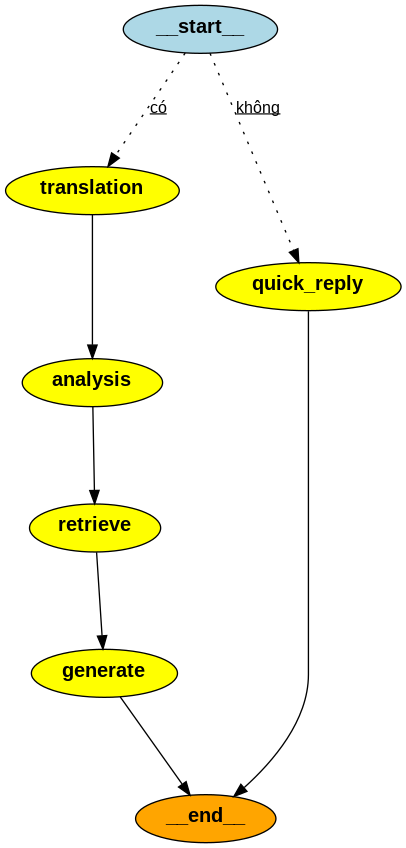

Router: Có
Translated query:
 Thủ tục và hồ sơ cần thiết để thành lập một công ty TNHH một thành viên như thế nào?
Tôi có thể nộp đơn đăng ký kinh doanh ở đâu và cần chuẩn bị giấy tờ gì không?
Ai là người chịu trách nhiệm pháp lý đối với công ty TNHH một thành viên trong trường hợp đó là cá nhân, hay tổ chức?
Chi phí thành lập công ty TNHH một thành viên bao gồm những khoản nào?
Tôi muốn hỏi về thủ tục thành lập công ty TNHH một thành viên.
{'translation': {'query': ['Thủ tục và hồ sơ cần thiết để thành lập một công ty TNHH một thành viên như thế nào?', 'Tôi có thể nộp đơn đăng ký kinh doanh ở đâu và cần chuẩn bị giấy tờ gì không?', 'Ai là người chịu trách nhiệm pháp lý đối với công ty TNHH một thành viên trong trường hợp đó là cá nhân, hay tổ chức?', 'Chi phí thành lập công ty TNHH một thành viên bao gồm những khoản nào?', 'Tôi muốn hỏi về thủ tục thành lập công ty TNHH một thành viên.']}}
{'analysis': {'structured_query': ['Thủ tục và hồ sơ cần thiết để thành lập một công ty TNHH một

In [7]:
with MongoDBSaver.from_conn_string(f"{MONGO_URI}{CHECKPOINT_DB}") as checkpointer:
    # graph_builder.add_edge(quick_reply, END)
    graph = graph_builder.compile(checkpointer=checkpointer)
    
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_png()))
    
    config = {"configurable": {"thread_id": "1"}}

    outputs = graph.stream({"messages": {"type": "human" , "content" : "Tôi muốn hỏi về thủ tục thành lập công ty TNHH một thành viên."}}, config=config)
    for output in outputs:
        print(output)
        
    checkpointer.get_tuple(config=config)
        
    outputs = graph.stream({"messages": {"type": "human" , "content" : "Thời tiết hôm nay như thế nào?"}}, config=config)
    for output in outputs:
        print(output)

In [9]:
with MongoDBSaver.from_conn_string(f"{MONGO_URI}{CHECKPOINT_DB}") as checkpointer:
    # graph_builder.add_edge(quick_reply, END)
    graph = graph_builder.compile(checkpointer=checkpointer)
    
    config = {"configurable": {"thread_id": "1"}}
    
    # print(checkpointer.get_tuple(config=config))
    print(list(checkpointer.list(config=config)))

[CheckpointTuple(config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f08ebeb-c48c-63c1-803c-80a4a5d02264'}}, checkpoint={'v': 4, 'ts': '2025-09-11T03:23:50.230097+00:00', 'id': '1f08ebeb-c48c-63c1-803c-80a4a5d02264', 'channel_values': {'messages': [HumanMessage(content='Tôi muốn hỏi về thủ tục thành lập công ty TNHH một thành viên.', additional_kwargs={}, response_metadata={}, id='1b452bbf-6b65-4f01-a6fb-bd762c5eba5b'), AIMessage(content=['Chào khách hàng!\n\nVậy, bạn muốn biết về thủ tục thành lập công ty trách nhiệm hữu hạn (TNHH) một thành viên. Theo pháp luật Việt Nam, để thành lập công ty TNHH một thành viên, bạn cần tuân theo các quy định tại Luật Doanh nghiệp số 68/2014/QH13 và Luật sửa đổi, bổ sung Điều 6 về Danh mục ngành, nghề đầu tư kinh doanh có điều kiện của Luật đầu tư số 67/2014/QH13.\n\nTheo Điều 40 của Luật Doanh nghiệp số 68/2014/QH13, công ty TNHH phải lập sổ đăng ký thành viên ngay sau khi đăng ký kinh doanh. Sổ đăng ký thành viên phải

In [10]:
with MongoDBSaver.from_conn_string(f"{MONGO_URI}{CHECKPOINT_DB}") as checkpointer:
    # graph_builder.add_edge(quick_reply, END)
    graph = graph_builder.compile(checkpointer=checkpointer)
    
    config = {"configurable": {"thread_id": "1"}}
    
    result = graph.invoke({"messages": {"type": "human" , "content" : "Các nguyên tắc của hôn nhân vào gia đình là gì?"}}, config=config)
    
    print(result)

Router response: 
{'messages': [HumanMessage(content='Tôi muốn hỏi về thủ tục thành lập công ty TNHH một thành viên.', additional_kwargs={}, response_metadata={}, id='1b452bbf-6b65-4f01-a6fb-bd762c5eba5b'), AIMessage(content=['Chào khách hàng!\n\nVậy, bạn muốn biết về thủ tục thành lập công ty trách nhiệm hữu hạn (TNHH) một thành viên. Theo pháp luật Việt Nam, để thành lập công ty TNHH một thành viên, bạn cần tuân theo các quy định tại Luật Doanh nghiệp số 68/2014/QH13 và Luật sửa đổi, bổ sung Điều 6 về Danh mục ngành, nghề đầu tư kinh doanh có điều kiện của Luật đầu tư số 67/2014/QH13.\n\nTheo Điều 40 của Luật Doanh nghiệp số 68/2014/QH13, công ty TNHH phải lập sổ đăng ký thành viên ngay sau khi đăng ký kinh doanh. Sổ đăng ký thành viên phải có các nội dung chủ yếu sau:\n\na) Tên, địa chỉ trụ sở chính của công ty;\n\nb) Họ, tên, địa chỉ thường trú, quốc tịch, số Giấy chứng minh nhân dân, Hộ chiếu hoặc chứng thực cá nhân hợp pháp khác đối với thành viên là cá nhân; tên, địa chỉ thường 

In [ ]:
# print(result["messages"][-1].content)
# print(result["context"])

print("Context:\n" + '\n'.join([f"{num + 1}/ {doc["document"].page_content}" for num, doc in enumerate(result['context'])]))
print(f"\n\nAnswer: {result['messages'][-1].content[0]}")

Context:
1/ QUỐC HỘI CỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM Độc lập - Tự do - Hạnh phúc Luật số: 68/2014/QH13 Hà Nội, ngày 26 tháng 11 năm 2014 LUẬT DOANH NGHIỆP Căn cứ Hiến pháp nước Cộng hòa xã hội chủ nghĩa Việt Nam; Quốc hội ban hành Luật doanh nghiệp. Chương INHỮNG QUY ĐỊNH CHUNG Điều 1. Phạm vi điều chỉnhLuật này quy định về việc thành lập, tổ chức quản lý, tổ chức lại, giải thể và hoạt động có liên quan của doanh nghiệp, bao gồm công ty trách nhiệm hữu hạn, công ty cổ phần, công ty hợp danh và doanh nghiệp tư nhân; quy định về nhóm công ty. Điều 2. Đối tượng áp dụng1. Các doanh nghiệp. 2. Cơ quan, tổ chức, cá nhân có liên quan đến việc thành lập, tổ chức quản lý, tổ chức lại, giải thể và hoạt động có liên quan của doanh nghiệp. Điều 3. Áp dụng Luật doanh nghiệp và các luật chuyên ngànhTrường hợp luật chuyên ngành có quy định đặc thù về việc thành lập, tổ chức quản lý, tổ chức lại, giải thể và hoạt động có liên quan của doanh nghiệp thì áp dụng quy định của Luật đó. Điều 4. Giải thíc

In [12]:
# def stream_graph_updates(input_from_user: str):
#     for step in graph.stream({"user_input": [input_from_user]}, config=config):
#         for output in step.values():
#             if output.get("answer") is not None:
#                 print("Assistant:", output["answer"][-1])


# while True:
#     try:
#         input_from_user = input("User: ")
#         if input_from_user.lower() in ["quit", "exit", "q"]:
#             print("Tạm biệt!")
#             break
#         stream_graph_updates(input_from_user)
#     except:
#         # fallback if input() is not available
#         input_from_user = "Điều đầu tiên được quy định trong Hiến pháp Việt Nam là gì"
#         print("User: " + input_from_user)
#         stream_graph_updates(input_from_user)
#         break